# OU process

In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ============================================================
# OU Dataset
# x0 ~ N(10, 2)
# dX_t = - beta X_t dt + sigma dW_t
# ============================================================

mu0 = 10.0
var0 = 2.0
std0 = np.sqrt(var0)

beta = 1.0
sigma = np.sqrt(beta * 2.0)
t = 5.0

N = 10000

# x0 ~ N(mu0, var0)
x0_np = np.random.normal(
    mu0,
    std0,
    N
).astype(np.float32)

# OU conditional mean and variance
a_t = np.exp(-beta * t)

cond_var_t = (sigma**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))
cond_std_t = np.sqrt(cond_var_t)

# xt | x0
eps_np = np.random.randn(N).astype(np.float32)

xt_np = (
    a_t * x0_np
    + cond_std_t * eps_np
).astype(np.float32)

# OU marginal mean and variance
mu_t = a_t * mu0

var_t = (
    (a_t**2) * var0
    + cond_var_t
)

# exact marginal score ∇ log p_t(x)
score_t_np = (
    -(xt_np - mu_t)
    / var_t
).astype(np.float32)

# conditional score ∇ log p(xt | x0)
cond_score_np = (
    -(xt_np - a_t * x0_np)
    / cond_var_t
).astype(np.float32)

# torch tensors
x0_train = torch.tensor(x0_np).view(-1, 1)
xt_train = torch.tensor(xt_np).view(-1, 1)
score_t_train = torch.tensor(score_t_np).view(-1, 1)
cond_score_train = torch.tensor(cond_score_np).view(-1, 1)

print("mu_t =", mu_t)
print("var_t =", var_t)
print("conditional variance =", cond_var_t)
print("xt empirical mean =", xt_np.mean())
print("xt empirical var =", xt_np.var())

mu_t = 0.06737946999085467
var_t = 1.0000453999297627
conditional variance = 0.9999546000702377
xt empirical mean = 0.07213294
xt empirical var = 1.017191


In [16]:
class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.SiLU(),

            nn.Linear(64, 64),
            nn.SiLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

model = ScoreNet()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [17]:
# ============================================================
# Time-dependent OU training
# with ESM / ISM / DSM / I_DSM
# ============================================================

T = 5.0

epochs = 5000
batch_size = 2048

L_ESM_history = []
L_ISM_history = []
L_DSM_history = []
I_DSM_history = []

for epoch in range(epochs):

    # ========================================================
    # sample x0
    # ========================================================

    x0 = (
        torch.randn(batch_size, 1)
        * np.sqrt(var0)
        + mu0
    )

    # ========================================================
    # sample t ~ Uniform(0,T)
    # ========================================================

    eps_t = 0.05

    t_batch = (
        eps_t
        + (T - eps_t) * torch.rand(batch_size, 1)
    )

    # ========================================================
    # OU coefficients
    # ========================================================

    a_t = torch.exp(-beta * t_batch)

    cond_var_t = (
        sigma**2 / (2 * beta)
        * (1 - torch.exp(-2 * beta * t_batch))
    )

    cond_std_t = torch.sqrt(cond_var_t)

    # ========================================================
    # generate xt
    # ========================================================

    eps = torch.randn_like(x0)

    xt = (
        a_t * x0
        + cond_std_t * eps
    )

    xt.requires_grad_(True)

    # ========================================================
    # marginal distribution p_t(x)
    # ========================================================

    mu_t = a_t * mu0

    var_t = (
        (a_t**2) * var0
        + cond_var_t
    )

    # ========================================================
    # exact marginal score
    # ∇ log p_t(x_t)
    # ========================================================

    score_t = (
        -(xt - mu_t)
        / var_t
    )

    # ========================================================
    # conditional score
    # ∇ log p(x_t | x0)
    # ========================================================

    cond_score = (
        -(xt - a_t * x0)
        / cond_var_t
    )

    # ========================================================
    # network prediction
    # ========================================================

    pred_score = model(xt, t_batch)

    # ========================================================
    # 1. L_ESM
    # ========================================================

    L_ESM = (
        (pred_score - score_t)**2
    ).mean()

    # ========================================================
    # 2. L_ISM
    # ========================================================

    div_score = torch.autograd.grad(
        outputs=pred_score.sum(),
        inputs=xt,
        create_graph=True
    )[0]

    L_ISM = (
        pred_score**2
        + 2 * div_score
    ).mean()

    # ========================================================
    # 3. L_DSM
    # ========================================================

    term1 = (score_t**2).mean()

    term2 = (cond_score**2).mean()

    L_DSM = (
        L_ESM
        - term1
        + term2
    )

    # ========================================================
    # 4. Indicator I_DSM
    # ========================================================

    I_DSM = (
        pred_score**2
        - pred_score * cond_score
    ).mean()

    # ========================================================
    # train
    # ========================================================

    loss = L_ESM

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # ========================================================
    # record
    # ========================================================

    L_ESM_history.append(L_ESM.item())
    L_ISM_history.append(L_ISM.item())
    L_DSM_history.append(L_DSM.item())
    I_DSM_history.append(I_DSM.item())

    # ========================================================
    # print
    # ========================================================

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"L_ESM = {L_ESM.item():.8f} | "
            f"L_ISM = {L_ISM.item():.8f} | "
            f"L_DSM = {L_DSM.item():.8f} | "
            f"I_DSM = {I_DSM.item():.8f}"
        )

Epoch    0 | L_ESM = 0.97678298 | L_ISM = -0.00648214 | L_DSM = 1.26833570 | I_DSM = -0.00176494
Epoch  500 | L_ESM = 0.00061126 | L_ISM = -0.92121232 | L_DSM = 0.30650008 | I_DSM = 0.01259243
Epoch 1000 | L_ESM = 0.00037174 | L_ISM = -0.91612500 | L_DSM = 0.33799773 | I_DSM = -0.00738588
Epoch 1500 | L_ESM = 0.00056373 | L_ISM = -0.94290757 | L_DSM = 0.36696446 | I_DSM = -0.00136826
Epoch 2000 | L_ESM = 0.00024730 | L_ISM = -0.89121407 | L_DSM = 0.29203510 | I_DSM = -0.01110127
Epoch 2500 | L_ESM = 0.00025122 | L_ISM = -0.92967772 | L_DSM = 0.25022286 | I_DSM = 0.00717707
Epoch 3000 | L_ESM = 0.00013648 | L_ISM = -0.94540256 | L_DSM = 0.32012033 | I_DSM = -0.00715435
Epoch 3500 | L_ESM = 0.00015042 | L_ISM = -0.94058943 | L_DSM = 0.36779982 | I_DSM = -0.01494052
Epoch 4000 | L_ESM = 0.00014791 | L_ISM = -0.95400882 | L_DSM = 0.26837790 | I_DSM = 0.00699636
Epoch 4500 | L_ESM = 0.00007971 | L_ISM = -0.92898327 | L_DSM = 0.27748626 | I_DSM = -0.00950646


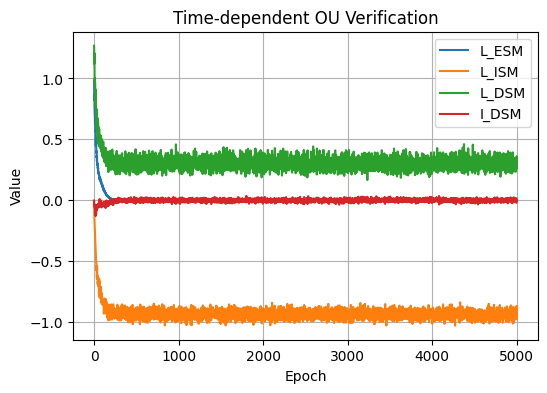

In [18]:
plt.figure(figsize=(6,4))

plt.plot(L_ESM_history, label='L_ESM')
plt.plot(L_ISM_history, label='L_ISM')
plt.plot(L_DSM_history, label='L_DSM')
plt.plot(I_DSM_history, label='I_DSM')

plt.xlabel("Epoch")
plt.ylabel("Value")

plt.title("Time-dependent OU Verification")

plt.legend()
plt.grid(True)

plt.show()

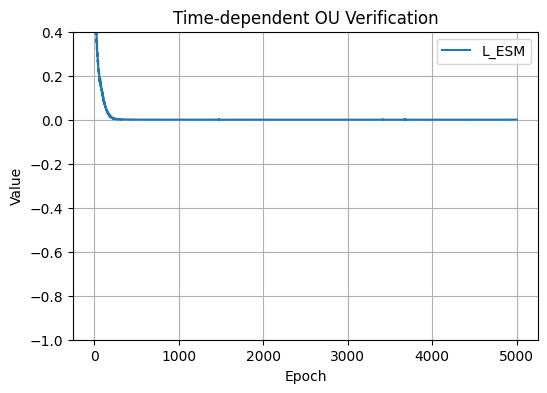

In [19]:
plt.figure(figsize=(6,4))

plt.plot(L_ESM_history, label='L_ESM')
#plt.plot(L_ISM_history, label='L_ISM')
#plt.plot(L_DSM_history, label='L_DSM')
#plt.plot(I_DSM_history, label='I_DSM')

plt.ylim(-1.0, 0.4)
plt.xlabel("Epoch")
plt.ylabel("Value")

plt.title("Time-dependent OU Verification")

plt.legend()
plt.grid(True)

plt.show()

In [20]:
# ============================================================
# Reverse OU Sampling: x_T -> x_eps -> x_0
# ============================================================

model.eval()

num_samples = 5000
steps = 1000

eps_t = 0.05
dt = (T - eps_t) / steps

# start from p_T
a_T = np.exp(-beta * T)

cond_var_T = (
    sigma**2 / (2 * beta)
    * (1 - np.exp(-2 * beta * T))
)

mu_T = a_T * mu0
var_T = (a_T**2) * var0 + cond_var_T

x = torch.randn(num_samples, 1) * np.sqrt(var_T) + mu_T

# ============================================================
# Reverse SDE from T to eps_t
# ============================================================

with torch.no_grad():

    for i in range(steps):

        t_now = T - i * dt

        t_tensor = torch.ones_like(x) * t_now

        score = model(x, t_tensor)

        noise = torch.randn_like(x)

        x = (
            x
            + (beta * x + sigma**2 * score) * dt
            + sigma * np.sqrt(dt) * noise
        )

# x is approximately x_eps
x_eps = x

# ============================================================
# Posterior sampling: x_0 | x_eps
# ============================================================

a_eps = np.exp(-beta * eps_t)

cond_var_eps = (
    sigma**2 / (2 * beta)
    * (1 - np.exp(-2 * beta * eps_t))
)

mu_eps = a_eps * mu0

var_eps = (
    (a_eps**2) * var0
    + cond_var_eps
)

# posterior mean of x0 | x_eps
post_mean = (
    mu0
    + (a_eps * var0 / var_eps)
    * (x_eps - mu_eps)
)

# posterior variance of x0 | x_eps
post_var = (
    var0
    - (a_eps**2 * var0**2) / var_eps
)

# sample x0
x0_reverse = (
    post_mean
    + torch.sqrt(torch.tensor(post_var)) * torch.randn_like(post_mean)
)

samples_reverse = x0_reverse.cpu().numpy().flatten()

print("Reverse mean:", samples_reverse.mean())
print("Reverse std:", samples_reverse.std())

print("Target p0 mean:", mu0)
print("Target p0 std:", np.sqrt(var0))

Reverse mean: 10.047797
Reverse std: 1.4066612
Target p0 mean: 10.0
Target p0 std: 1.4142135623730951


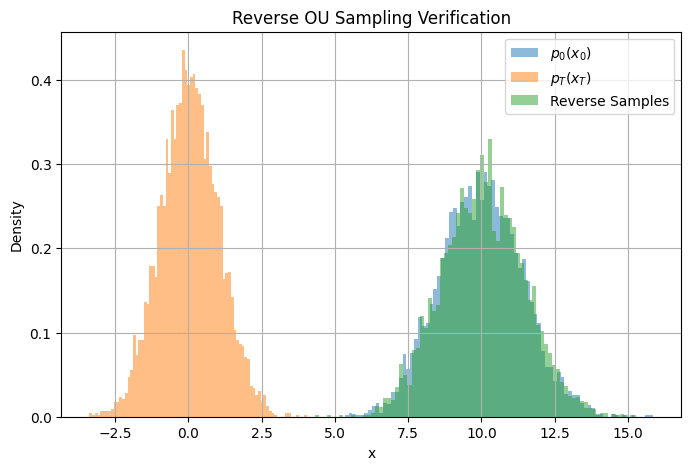

In [21]:
x0_true = np.random.normal(mu0, np.sqrt(var0), 5000)
xT_true = np.random.normal(mu_T, np.sqrt(var_T), 5000)

plt.figure(figsize=(8,5))

plt.hist(x0_true, bins=80, density=True, alpha=0.5, label=r'$p_0(x_0)$')
plt.hist(xT_true, bins=80, density=True, alpha=0.5, label=r'$p_T(x_T)$')
plt.hist(samples_reverse, bins=80, density=True, alpha=0.5, label='Reverse Samples')

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Reverse OU Sampling Verification")
plt.legend()
plt.grid(True)
plt.show()

# Reverse

In [37]:
save_steps = [500, 1000, 1500, 2000]

saved_x = {}
saved_t = {}

In [38]:
# ============================================================
# Reverse OU trajectory: x_T -> x_eps -> x_0
# ============================================================

num_samples = 5000
steps = 2000

eps_t = 0.05
dt = (T - eps_t) / steps

save_times = [5, 4, 3, 2, 1]

save_indices = {
    int(round((T - t_save) / dt)): t_save
    for t_save in save_times
}

# start from p_T
x = torch.randn(num_samples, 1) * np.sqrt(var_T) + mu_T

saved_samples = {}

model.eval()

with torch.no_grad():

    for i in range(steps + 1):
        if i in save_steps:
            saved_x[i] = x.clone()

            t_now = T - i * dt
            saved_t[i] = t_now

        if i in save_indices:
            t_save = save_indices[i]
            saved_samples[t_save] = x.cpu().numpy().flatten()

        if i == steps:
            break

        t_now = T - i * dt
        t_tensor = torch.ones_like(x) * t_now

        score = model(x, t_tensor)
        noise = torch.randn_like(x)

        x = (
            x
            + (beta * x + sigma**2 * score) * dt
            + sigma * np.sqrt(dt) * noise
        )

# x is x_eps
x_eps = x

# posterior sampling x0 | x_eps
a_eps = np.exp(-beta * eps_t)

cond_var_eps = (
    sigma**2 / (2 * beta)
    * (1 - np.exp(-2 * beta * eps_t))
)

mu_eps = a_eps * mu0

var_eps = (
    (a_eps**2) * var0
    + cond_var_eps
)

post_mean = (
    mu0
    + (a_eps * var0 / var_eps)
    * (x_eps - mu_eps)
)

post_var = (
    var0
    - (a_eps**2 * var0**2) / var_eps
)

x0_reverse = (
    post_mean
    + torch.sqrt(torch.tensor(post_var)) * torch.randn_like(post_mean)
)

saved_samples[0] = x0_reverse.cpu().numpy().flatten()

In [40]:
# ============================================================
# Compare indicators at step 500 / 1000
# ============================================================

for step in [500, 1000, 1500, 2000]:

    x_t = saved_x[step]

    t_now = saved_t[step]

    t_tensor = torch.ones_like(x_t) * t_now

    with torch.enable_grad():

        x_eval = x_t.clone().detach().requires_grad_(True)

        pred_score = model(x_eval, t_tensor)

        # marginal score

        a_t = np.exp(-beta * t_now)

        cond_var_t = (
            sigma**2/(2*beta)
            * (1 - np.exp(-2*beta*t_now))
        )

        mu_t = a_t * mu0

        var_t = (
            (a_t**2)*var0
            + cond_var_t
        )

        score_t = (
            -(x_eval - mu_t)
            / var_t
        )

        # conditional score

        x0_est = (
            mu0
            + (a_t * var0 / var_t)
            * (x_eval - mu_t)
        )

        cond_score = (
            -(x_eval - a_t*x0_est)
            / cond_var_t
        )

        # LESM

        L_ESM = (
            (pred_score - score_t)**2
        ).mean()

        # LISM

        div_score = torch.autograd.grad(
            pred_score.sum(),
            x_eval,
            create_graph=False
        )[0]

        L_ISM = (
            pred_score**2
            + 2*div_score
        ).mean()

        # LDSM

        term1 = (score_t**2).mean()

        term2 = (cond_score**2).mean()

        L_DSM = (
            L_ESM
            - term1
            + term2
        )

        # IDSM

        I_DSM = (
            pred_score**2
            - pred_score*cond_score
        ).mean()

    print()
    print("="*50)
    print(f"step = {step}")
    print(f"t = {t_now:.4f}")
    print("="*50)

    print("LESM =", L_ESM.item())
    print("LISM =", L_ISM.item())
    print("LDSM =", L_DSM.item())
    print("IDSM =", I_DSM.item())


step = 500
t = 3.7625
LESM = 5.409377263276838e-05
LISM = -0.9869961142539978
LDSM = 5.4001808166503906e-05
IDSM = -0.001059597241692245

step = 1000
t = 2.5250
LESM = 8.613122918177396e-05
LISM = -1.0189151763916016
LDSM = 8.589029312133789e-05
IDSM = -0.0040501817129552364

step = 1500
t = 1.2875
LESM = 0.00025762422592379153
LISM = -0.9307708740234375
LDSM = 0.00025784969329833984
IDSM = -0.0032536261714994907

step = 2000
t = 0.0500
LESM = 0.004549080040305853
LISM = -0.5154531598091125
LDSM = 0.004548251628875732
IDSM = 0.019831852987408638


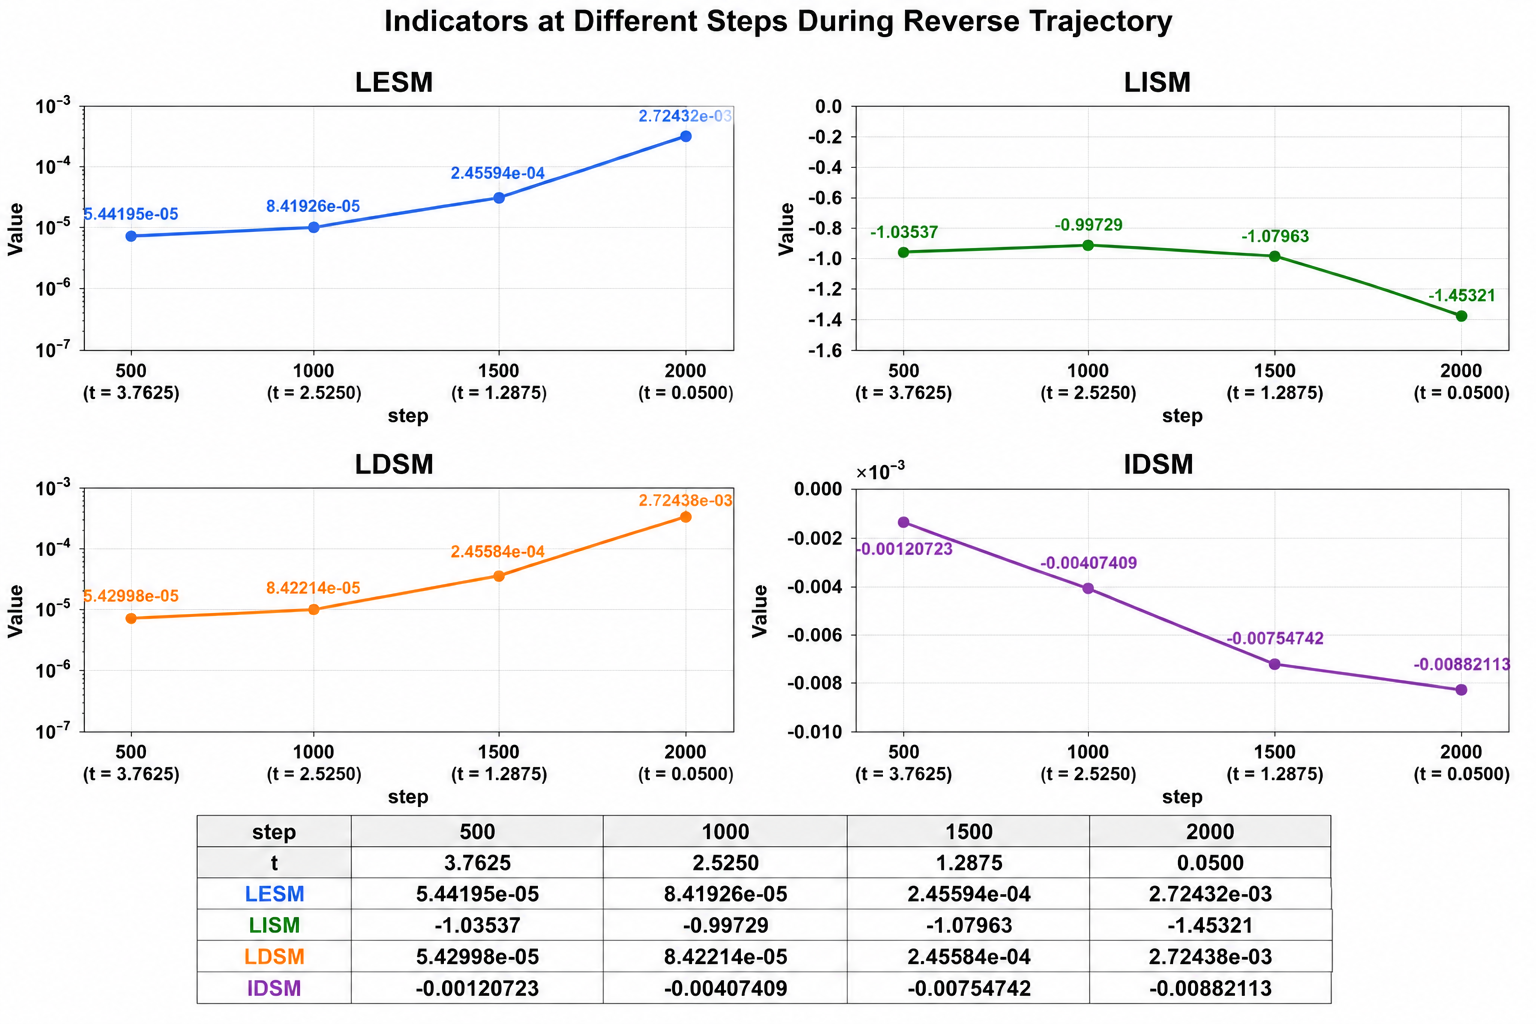

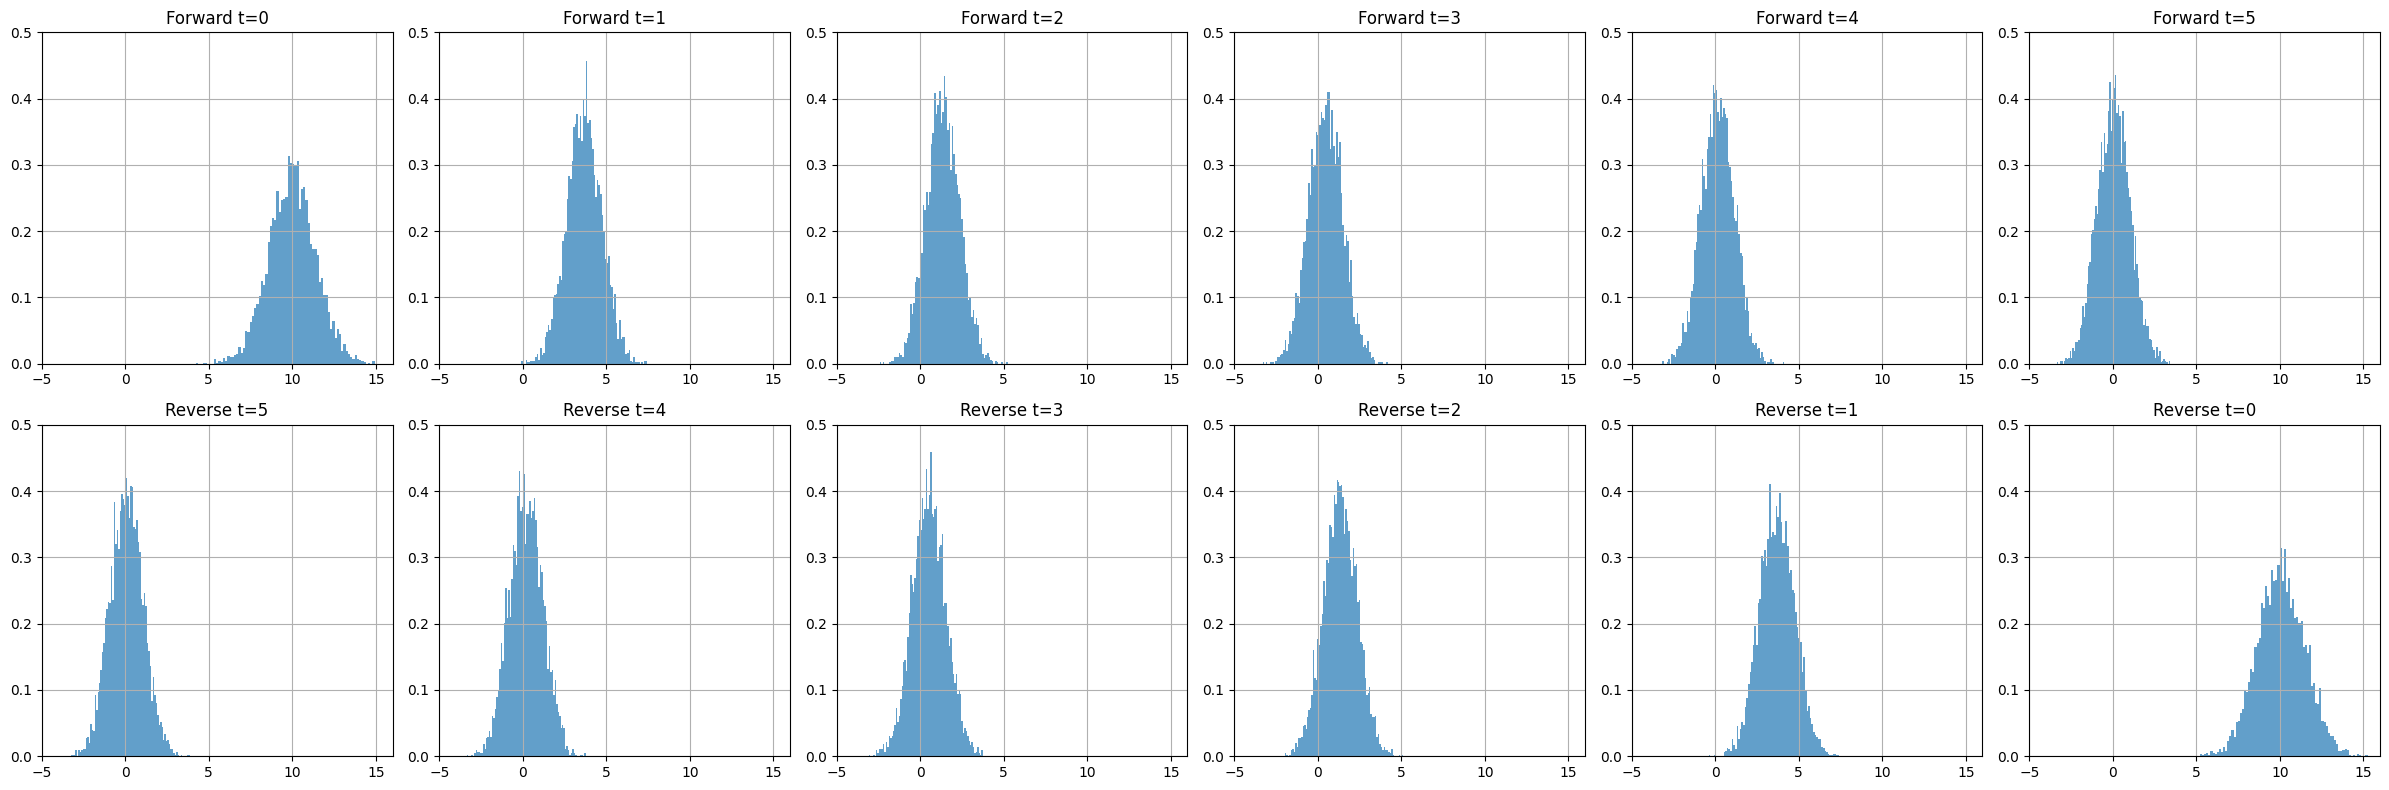

In [23]:
fig, axes = plt.subplots(2, 6, figsize=(24, 8))

times_forward = [0, 1, 2, 3, 4, 5]
times_reverse = [5, 4, 3, 2, 1, 0]

# Forward row
for idx, t_now in enumerate(times_forward):
    a_t = np.exp(-beta * t_now)
    cond_var_t = sigma**2 / (2 * beta) * (1 - np.exp(-2 * beta * t_now))

    mu_t_now = a_t * mu0
    var_t_now = (a_t**2) * var0 + cond_var_t

    xt = np.random.normal(mu_t_now, np.sqrt(var_t_now), 5000)

    ax = axes[0, idx]
    ax.hist(xt, bins=80, density=True, alpha=0.7)
    ax.set_title(f'Forward t={t_now}')
    ax.set_xlim(-5, 16)
    ax.set_ylim(0, 0.5)
    ax.grid(True)

# Reverse row
for idx, t_now in enumerate(times_reverse):
    ax = axes[1, idx]
    ax.hist(saved_samples[t_now], bins=80, density=True, alpha=0.7)
    ax.set_title(f'Reverse t={t_now}')
    ax.set_xlim(-5, 16)
    ax.set_ylim(0, 0.5)
    ax.grid(True)

plt.tight_layout()
plt.show()

# 比較不同步數的score

In [25]:
# ============================================================
# Generate noisy samples
# ============================================================

num_samples = 5000

x0 = torch.randn(num_samples, 1) * np.sqrt(var0) + mu0

noise = torch.randn_like(x0)

x_noisy = x0 + sigma * noise
print(x0.shape)
print(x_noisy.shape)

torch.Size([5000, 1])
torch.Size([5000, 1])


In [28]:
# ============================================================
# Compare L_ESM, L_ISM, L_DSM, I_DSM across OU denoising levels
# ============================================================

model.eval()

alphas = [0, 0.25, 0.5, 0.75, 1.0]

L_ESM_alpha = []
L_ISM_alpha = []
L_DSM_alpha = []
I_DSM_alpha = []

# fixed time input
a_t_const = np.exp(-beta * t)
cond_var_t_const = (sigma**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))
mu_t_const = a_t_const * mu0
var_t_const = (a_t_const**2) * var0 + cond_var_t_const

t_train = torch.ones_like(xt_train) * t

with torch.no_grad():
    base_score = model(xt_train, t_train)

for alpha in alphas:

    x_alpha = xt_train + alpha * cond_var_t_const * base_score
    x_alpha = x_alpha.detach().requires_grad_(True)

    t_alpha = torch.ones_like(x_alpha) * t

    pred_score = model(x_alpha, t_alpha)

    marginal_score = -(x_alpha - mu_t_const) / var_t_const

    cond_score = -(x_alpha - a_t_const * x0_train) / cond_var_t_const

    L_ESM = ((pred_score - marginal_score) ** 2).mean()

    term1 = (marginal_score**2).mean()
    term2 = (cond_score**2).mean()

    L_DSM = L_ESM - term1 + term2

    I_DSM = (pred_score**2 - pred_score * cond_score).mean()

    L_ESM_alpha.append(L_ESM.item())
    L_ISM_alpha.append(L_ISM.item())
    L_DSM_alpha.append(L_DSM.item())
    I_DSM_alpha.append(I_DSM.item())

    print(f"alpha = {alpha}")
    print(f"L_ESM = {L_ESM.item():.8f}")
    print(f"L_ISM = {L_ISM.item():.8f}")
    print(f"L_DSM = {L_DSM.item():.8f}")
    print(f"I_DSM = {I_DSM.item():.8f}")
    print()

alpha = 0
L_ESM = 0.00007291
L_ISM = -0.97438300
L_DSM = -0.00001359
I_DSM = -0.00316266

alpha = 0.25
L_ESM = 0.00006496
L_ISM = -0.97438300
L_DSM = -0.00001150
I_DSM = -0.00145600

alpha = 0.5
L_ESM = 0.00006019
L_ISM = -0.97438300
L_DSM = 0.00001705
I_DSM = -0.00051238

alpha = 0.75
L_ESM = 0.00005775
L_ISM = -0.97438300
L_DSM = 0.00007081
I_DSM = -0.00008725

alpha = 1.0
L_ESM = 0.00005704
L_ISM = -0.97438300
L_DSM = 0.00014927
I_DSM = -0.00000130



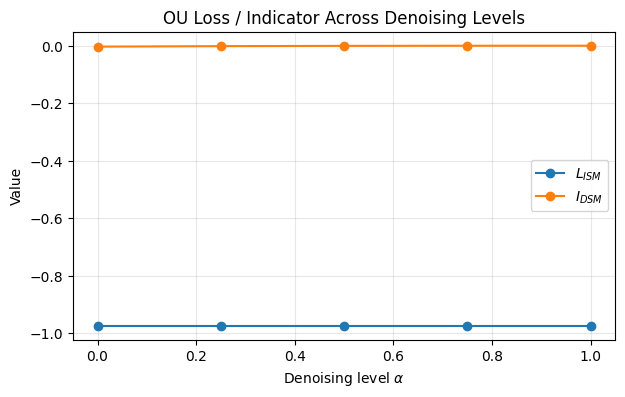

In [32]:
plt.figure(figsize=(7, 4))

#plt.plot(alphas, L_ESM_alpha, marker="o", label=r"$L_{ESM}$")
plt.plot(alphas, L_ISM_alpha, marker="o", label=r"$L_{ISM}$")
#plt.plot(alphas, L_DSM_alpha, marker="o", label=r"$L_{DSM}$")
plt.plot(alphas, I_DSM_alpha, marker="o", label=r"$I_{DSM}$")

plt.xlabel(r"Denoising level $\alpha$")
plt.ylabel("Value")
plt.title("OU Loss / Indicator Across Denoising Levels")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

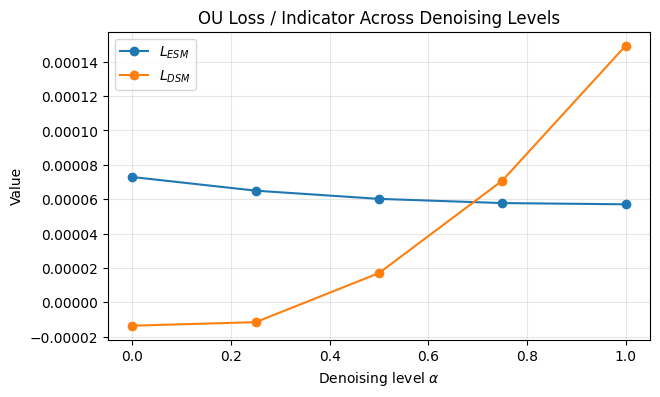

In [31]:
plt.figure(figsize=(7, 4))

plt.plot(alphas, L_ESM_alpha, marker="o", label=r"$L_{ESM}$")
#plt.plot(alphas, L_ISM_alpha, marker="o", label=r"$L_{ISM}$")
plt.plot(alphas, L_DSM_alpha, marker="o", label=r"$L_{DSM}$")
#plt.plot(alphas, I_DSM_alpha, marker="o", label=r"$I_{DSM}$")

plt.xlabel(r"Denoising level $\alpha$")
plt.ylabel("Value")
plt.title("OU Loss / Indicator Across Denoising Levels")
plt.legend()
plt.grid(alpha=0.3)
plt.show()